In [ ]:
from omegaconf import OmegaConf
from torch.utils.data import DataLoader
from torchaudio.transforms import AmplitudeToDB
import os

import torch

from pytorch_lightning import Trainer

from dataset.ai_synth_dataset import AiSynthDataset, NSynthDataset
from model.lit_module import LitModularSynth
import matplotlib.pyplot as plt

from librosa import amplitude_to_db

In [ ]:
cfg_path = r'configs/params_baseline.yaml'

dataset_to_visualize = 'modular_synth50k_new'
split_to_visualize = 'val_nsynth'

batch_size = 100
num_workers = 10
device = 'cuda:0'

In [ ]:

cfg = OmegaConf.load(cfg_path)
lit_module = LitModularSynth(cfg, device)

trainer = Trainer(devices=[device], accelerator="gpu", detect_anomaly=True)

In [ ]:
## Create dataset
data_dir = os.path.join('data', dataset_to_visualize, split_to_visualize, '')
nsynth_dataset = NSynthDataset(data_dir)
nsynth_loader = DataLoader(nsynth_dataset, batch_size=batch_size, num_workers=num_workers,
                           persistent_workers=(num_workers != 0))

In [ ]:
## Load model
model_ckpt_path1 = r'/home/almogelharar/almog/ai_synth/experiments/current/modular_synth_120e/ckpts/trained_synth_net.pt'
model_ckpt_path2 = r'/home/almogelharar/almog/ai_synth/experiments/current/modular_synth_40_40_40_min_param_decay01_cumsum_time/ckpts/synth_net_epoch70.pt'

In [119]:
res = []
for ckpt_path in [model_ckpt_path1, model_ckpt_path2]:
    ckpt = torch.load(ckpt_path)
    lit_module.synth_net.load_state_dict(ckpt['state_dict'])
    val_res = trainer.validate(model=lit_module, dataloaders=[nsynth_loader])
    res.append(val_res)

In [125]:
def plot_result(target_audio, pred_audio1, pred_audio2, target_spec, pred_spec1, pred_spec2):

    fig, ax = plt.subplots(2, 3, figsize=(20, 10))

    ax[0, 0].plot(target_audio)
    ax[0, 1].plot(pred_audio1)
    ax[0, 2].plot(pred_audio2)

    ax[1, 0].imshow(amplitude_to_db(target_spec), origin='lower', aspect='auto', cmap=plt.get_cmap('inferno'))
    ax[1, 1].imshow(amplitude_to_db(pred_spec1), origin='lower', aspect='auto', cmap=plt.get_cmap('inferno'))
    ax[1, 2].imshow(amplitude_to_db(pred_spec2), origin='lower', aspect='auto', cmap=plt.get_cmap('inferno'))

    plt.show()

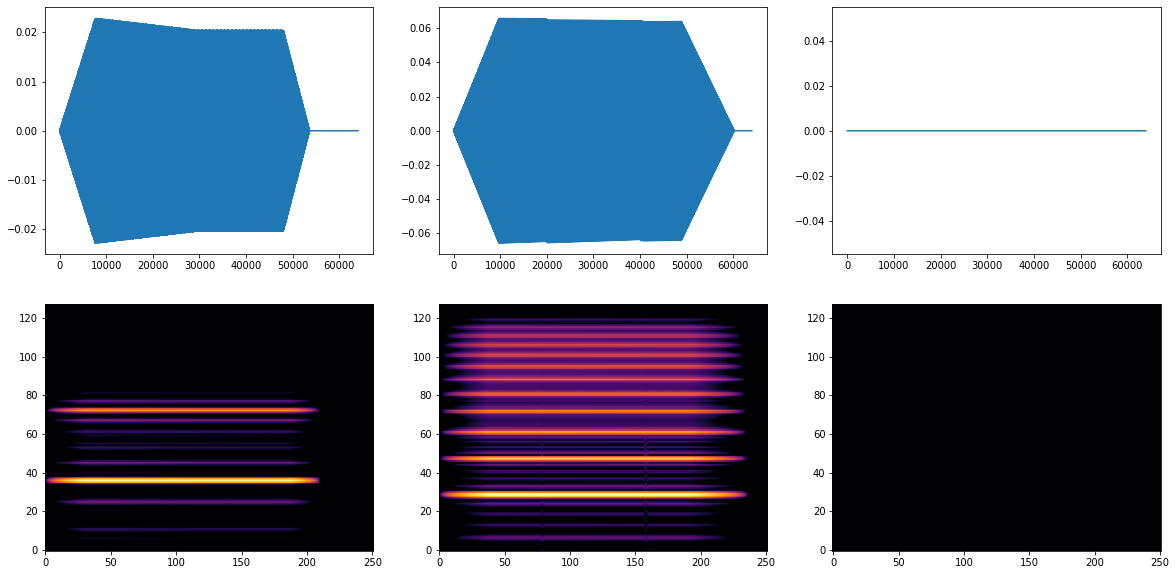

Sound 0 target

Sound 0 model1 prediction

Sound 0 model2 prediction

/home/noyuzrad/ai_synth/venv/lib/python3.8/site-packages/IPython/lib/display.py:187: RuntimeWarning: invalid value encountered in true_divide
  scaled = data / normalization_factor * 32767


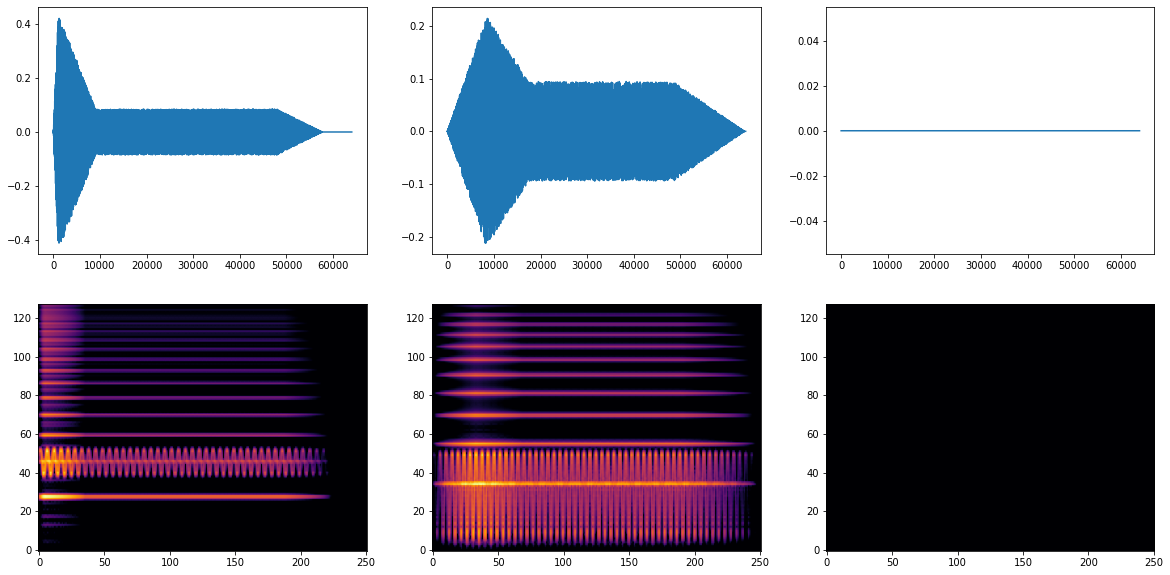

Sound 1 target

Sound 1 model1 prediction

Sound 1 model2 prediction

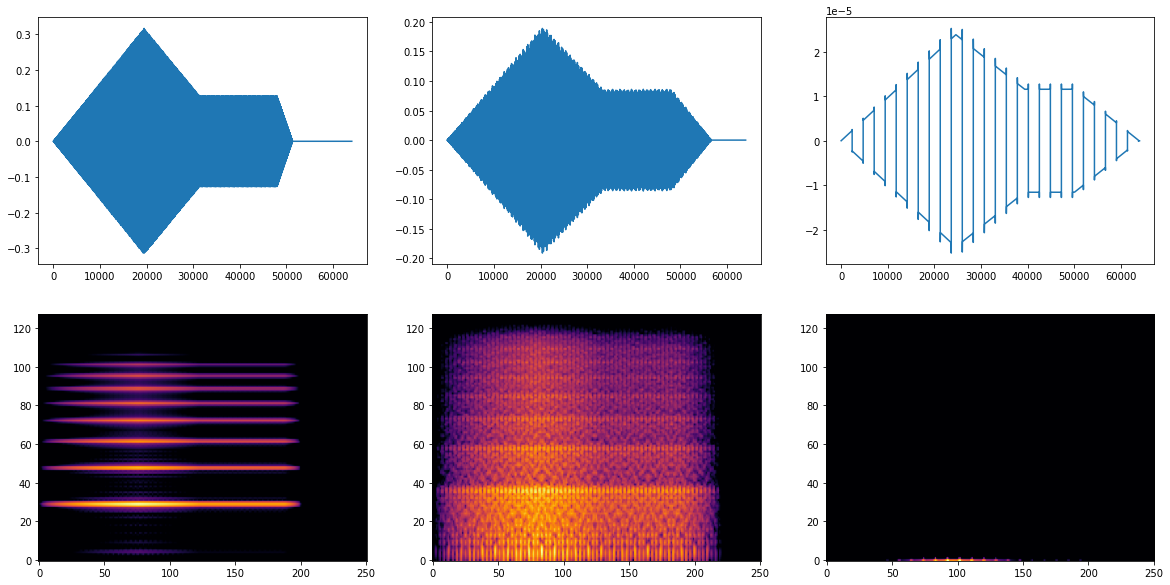

Sound 2 target

Sound 2 model1 prediction

Sound 2 model2 prediction

Exception ignored in: <function Wave_write.__del__ at 0x7fb7a09b1af0>
Traceback (most recent call last):
  File "/usr/lib/python3.8/wave.py", line 327, in __del__
    self.close()
  File "/usr/lib/python3.8/wave.py", line 445, in close
    self._ensure_header_written(0)
  File "/usr/lib/python3.8/wave.py", line 465, in _ensure_header_written
    raise Error('sample width not specified')
wave.Error: sample width not specified


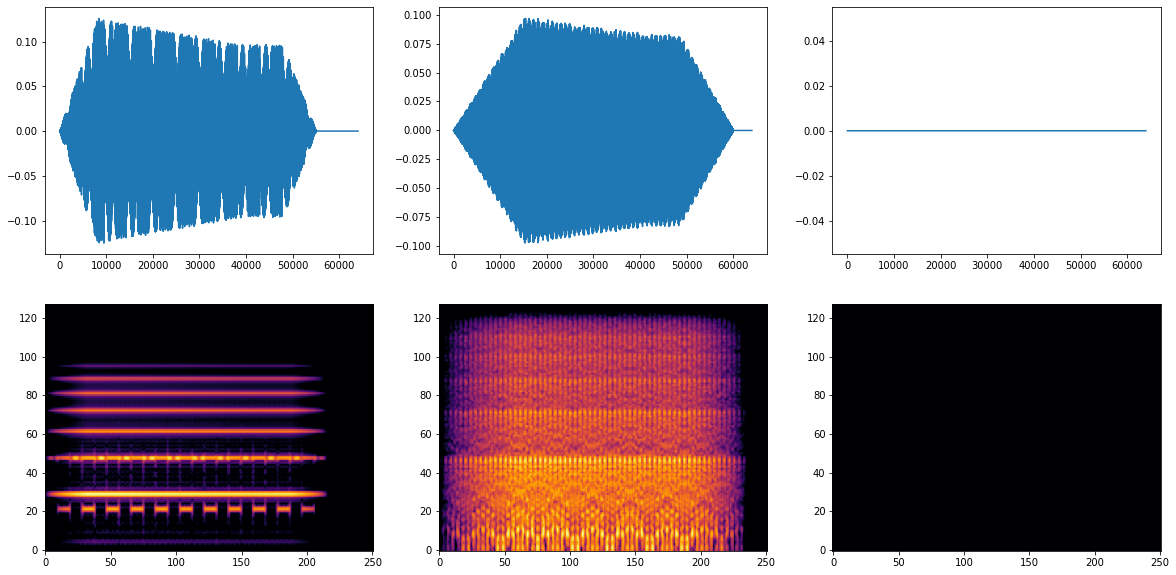

Sound 3 target

Sound 3 model1 prediction

Sound 3 model2 prediction

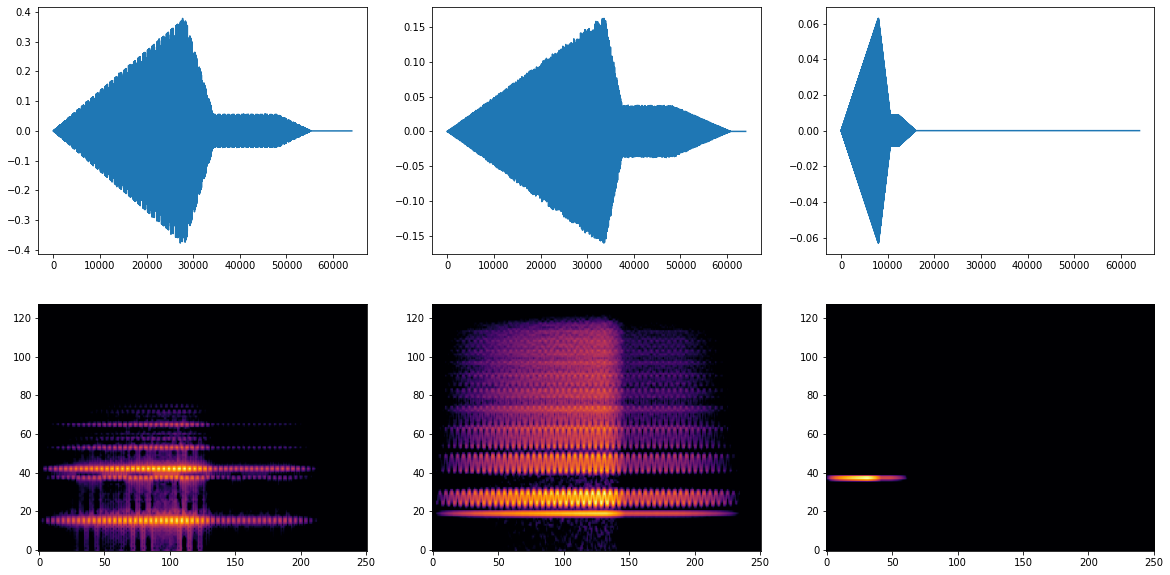

Sound 4 target

Sound 4 model1 prediction

Sound 4 model2 prediction

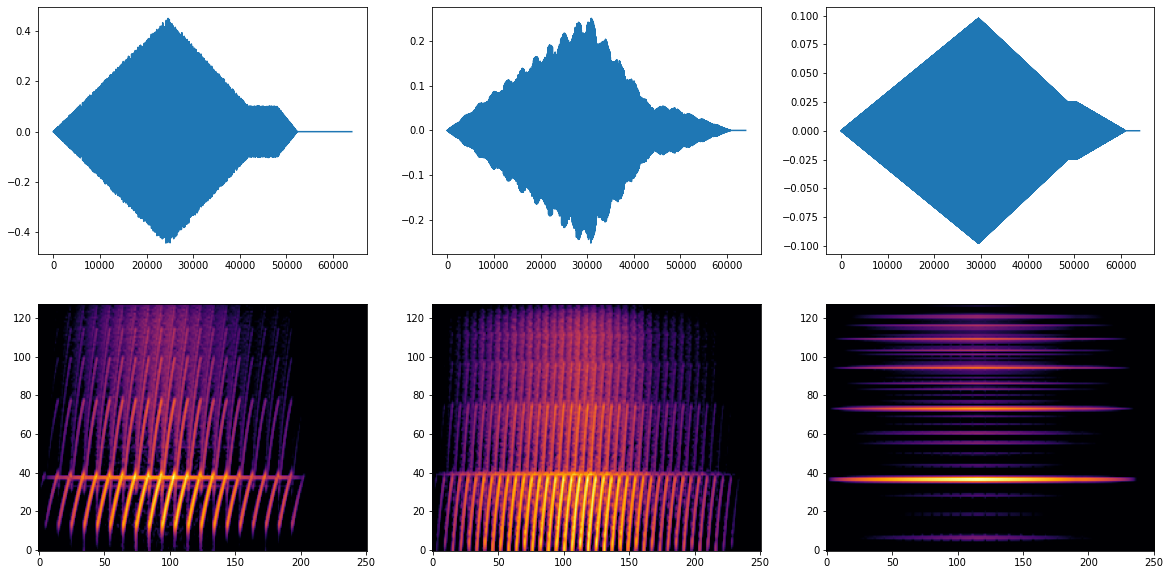

Sound 5 target

Sound 5 model1 prediction

Sound 5 model2 prediction

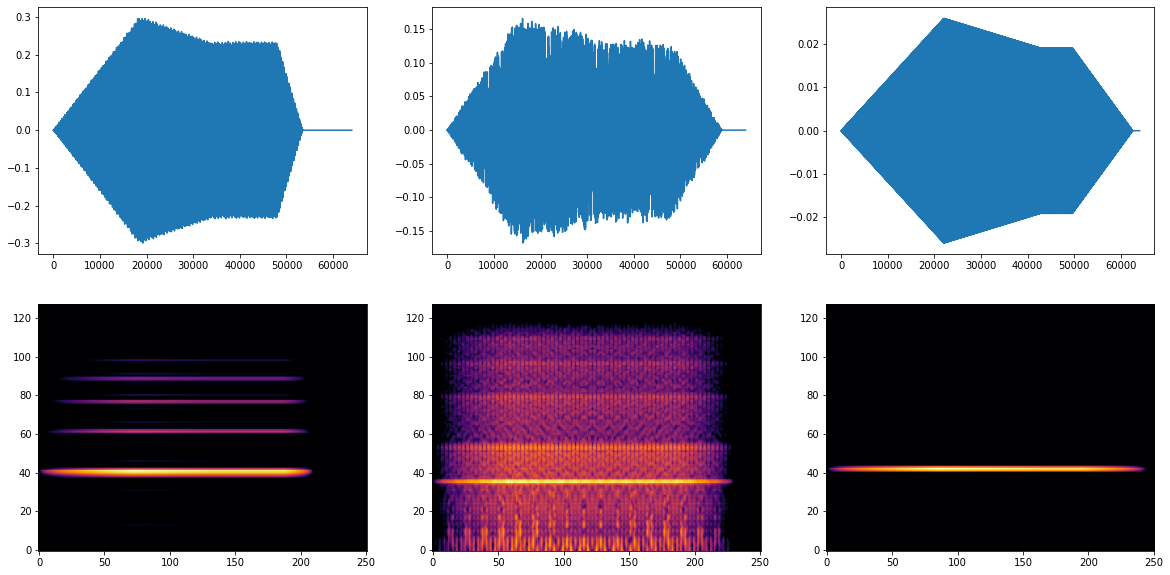

Sound 6 target

Sound 6 model1 prediction

Sound 6 model2 prediction

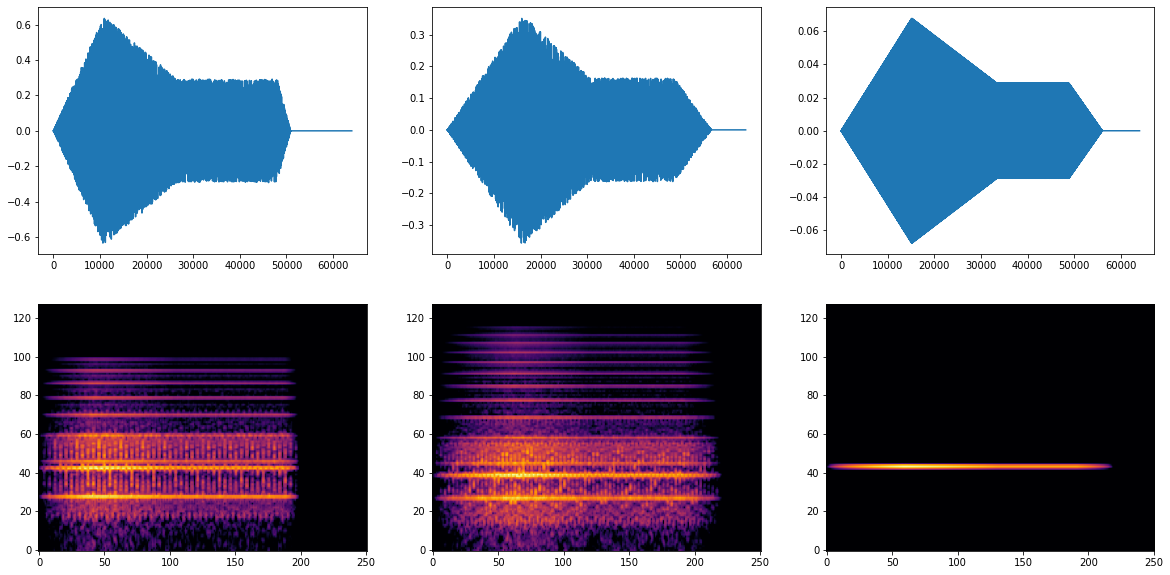

Sound 7 target

Sound 7 model1 prediction

Sound 7 model2 prediction

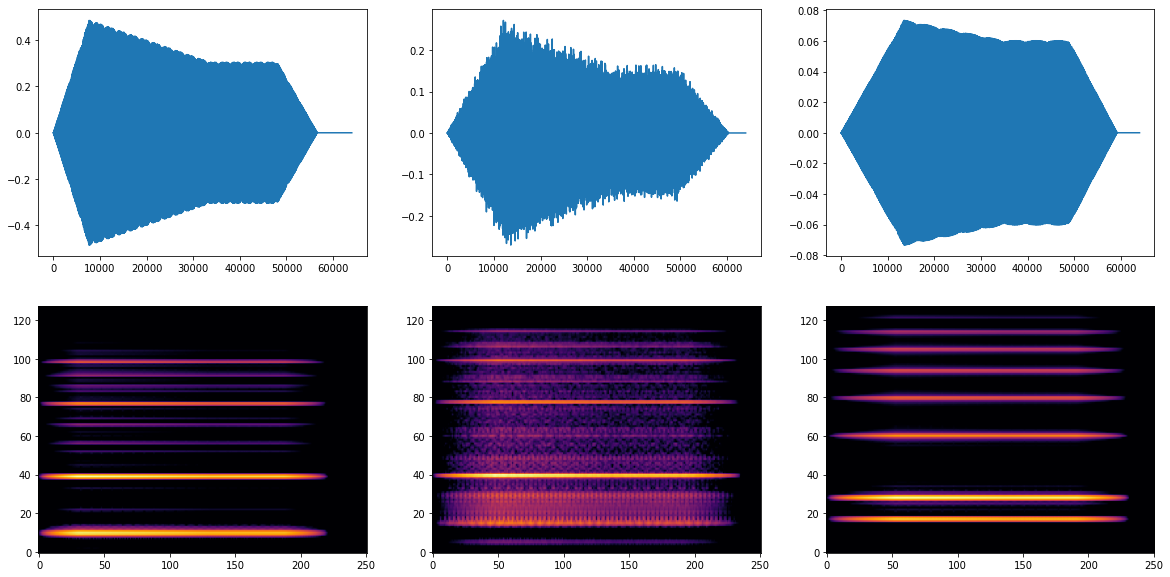

Sound 8 target

Sound 8 model1 prediction

Sound 8 model2 prediction

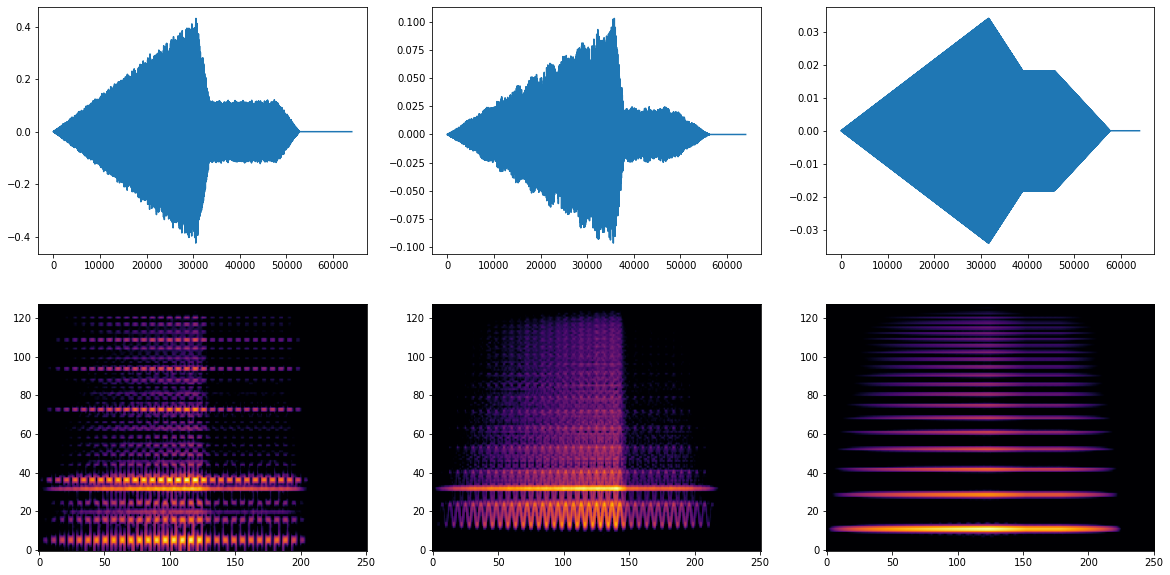

Sound 9 target

Sound 9 model1 prediction

Sound 9 model2 prediction

In [129]:
from IPython.display import display, Audio, Pretty


for i in range(batch_size):
    plot_result(results1['target_audio'][i], results1['predicted_audio'][i], results2['predicted_audio'][i],
                results1['target_spectrograms'][i], results1['predicted_spectrograms'][i], results2['predicted_spectrograms'][i])

    display(Pretty(f'Sound {i} target'))
    display(Audio(results1['target_audio'][i], rate=cfg.sample_rate, autoplay=False))

    display(Pretty(f'Sound {i} model1 prediction'))
    display(Audio(results1['predicted_audio'][i], rate=cfg.sample_rate, autoplay=False))

    display(Pretty(f'Sound {i} model2 prediction'))
    display(Audio(results2['predicted_audio'][i], rate=cfg.sample_rate, autoplay=False))